# Sri Lanka Flood Prediction Model Training
This notebook details the Exploratory Data Analysis (EDA) and Hyperparameter Optimization for predicting flood risk levels and estimating flood depth in Sri Lanka.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error
import pickle
import os

sns.set_theme(style='whitegrid')

## 1. Load the Actual Dataset

In [ ]:
dataset_path = r'D:\flood_predict\backend\dataset\sri_lanka_flood_risk_dataset.csv'
df = pd.read_csv(dataset_path)
df.head()

,date,location_lat,location_lon,daily_rainfall_mm,3_day_cumulative_rain,river_level_m,rate_of_rise,elevation_m,slope_degrees,distance_to_river_km,flood_occurred,flood_depth_m
0,10/9/2016,6.9738,80.90566,34.0,63.3,2.87,0.397,2.2,0.2,0.74,0,0.0
1,10/21/2016,6.9738,80.90566,7.6,18.9,2.68,0.207,2.2,0.2,0.74,0,0.0
2,11/16/2016,6.9738,80.90566,141.2,408.5,7.35,2.300,2.2,0.2,0.74,1,3.8
3,11/19/2016,6.9738,80.90566,0.3,1.2,1.91,-0.182,2.2,0.2,0.74,0,0.0
4,5/21/2017,6.9738,80.90566,2.1,14.3,2.39,-0.126,2.2,0.2,0.74,0,0.0


## 2. Basic Dataset Info

In [3]:
print('Dataset Shape:', df.shape)
df.info()
df.describe()

Dataset Shape: (9000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   9000 non-null   object 
 1   location_lat           9000 non-null   float64
 2   location_lon           9000 non-null   float64
 3   daily_rainfall_mm      9000 non-null   float64
 4   3_day_cumulative_rain  9000 non-null   float64
 5   river_level_m          9000 non-null   float64
 6   rate_of_rise           9000 non-null   float64
 7   elevation_m            9000 non-null   float64
 8   slope_degrees          9000 non-null   float64
 9   distance_to_river_km   9000 non-null   float64
 10  flood_occurred         9000 non-null   int64  
 11  flood_depth_m          9000 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 843.9+ KB


,location_lat,location_lon,daily_rainfall_mm,3_day_cumulative_rain,river_level_m,rate_of_rise,elevation_m,slope_degrees,distance_to_river_km,flood_occurred,flood_depth_m
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.00000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.258417,80.657875,22.743978,59.897144,2.37233,0.222487,28.159500,2.334900,3.252350,0.122444,0.276762
std,0.764841,0.526111,37.513151,93.619365,1.37872,0.574341,27.621184,2.352379,3.198426,0.327817,0.797847
min,6.014360,79.759110,0.000000,0.000000,0.05000,-0.581000,0.500000,0.050000,0.020000,0.000000,0.000000
25%,6.594317,80.220630,0.900000,6.100000,1.42000,-0.128000,8.200000,0.597500,0.855000,0.000000,0.000000
50%,7.285665,80.724950,4.300000,15.550000,2.11500,-0.005000,19.700000,1.705000,2.435000,0.000000,0.000000
75%,7.967833,81.085955,27.600000,69.325000,2.99000,0.303000,41.050000,3.222500,4.475000,0.000000,0.000000
max,8.565910,81.532910,290.000000,856.600000,9.20000,2.300000,184.300000,16.180000,17.310000,1.000000,3.800000


## 2.1. Date Column Conversion and Feature Engineering

Let's convert the `date` column to datetime objects and extract useful temporal features. This will enable time-series analysis and provide additional features for our models.

In [13]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

print('DataFrame after adding temporal features:')
display(df.head())

DataFrame after adding temporal features:


,date,location_lat,location_lon,daily_rainfall_mm,3_day_cumulative_rain,river_level_m,rate_of_rise,elevation_m,slope_degrees,distance_to_river_km,flood_occurred,flood_depth_m,risk_level,year,month,day,dayofweek
0,2016-10-09,6.9738,80.90566,34.0,63.3,2.87,0.397,2.2,0.2,0.74,0,0.0,0,2016,10,9,6
1,2016-10-21,6.9738,80.90566,7.6,18.9,2.68,0.207,2.2,0.2,0.74,0,0.0,0,2016,10,21,4
2,2016-11-16,6.9738,80.90566,141.2,408.5,7.35,2.300,2.2,0.2,0.74,1,3.8,3,2016,11,16,2
3,2016-11-19,6.9738,80.90566,0.3,1.2,1.91,-0.182,2.2,0.2,0.74,0,0.0,0,2016,11,19,5
4,2017-05-21,6.9738,80.90566,2.1,14.3,2.39,-0.126,2.2,0.2,0.74,0,0.0,0,2017,5,21,6


### Distribution of Flood Events by Month and Day of Week

Visualizing flood occurrences across different months and days of the week can reveal seasonal patterns or weekly trends.

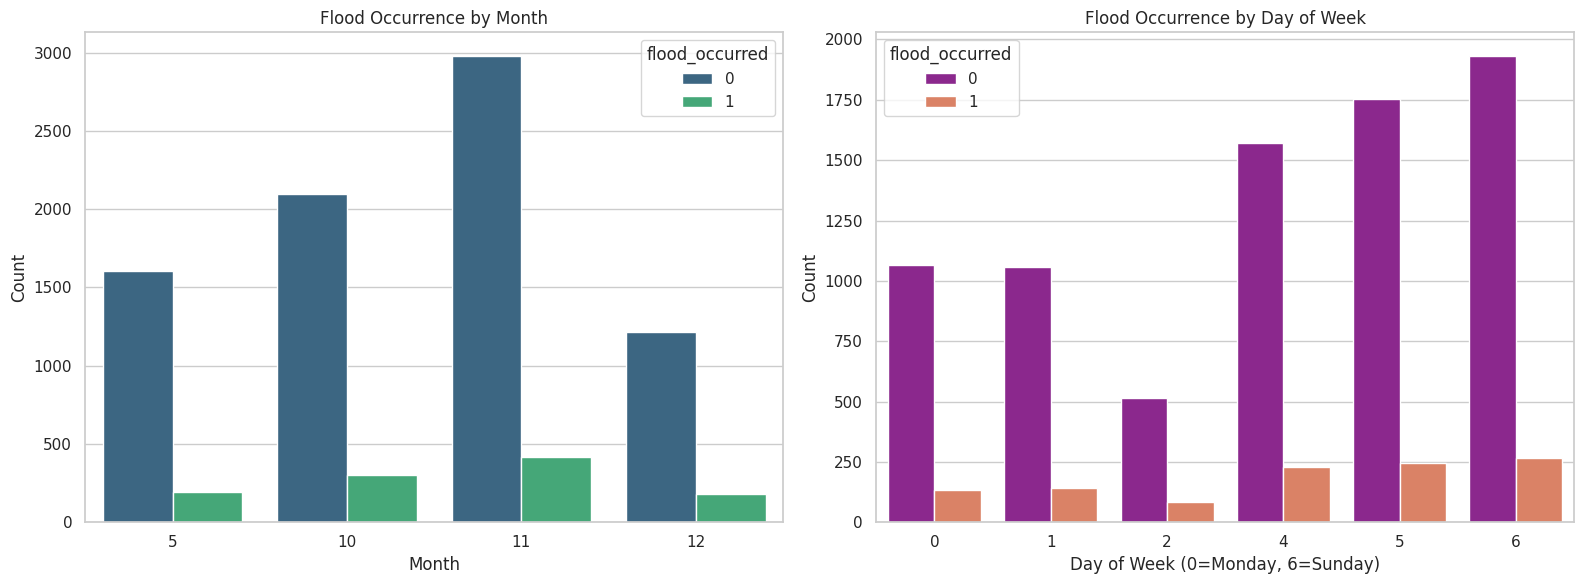

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='month', hue='flood_occurred', palette='viridis', ax=axes[0])
axes[0].set_title('Flood Occurrence by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='dayofweek', hue='flood_occurred', palette='plasma', ax=axes[1])
axes[1].set_title('Flood Occurrence by Day of Week')
axes[1].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3.1. More In-depth EDA: Numerical Feature Distributions

Let's visualize the distributions of our key numerical features to understand their spread and identify potential skewness or outliers.

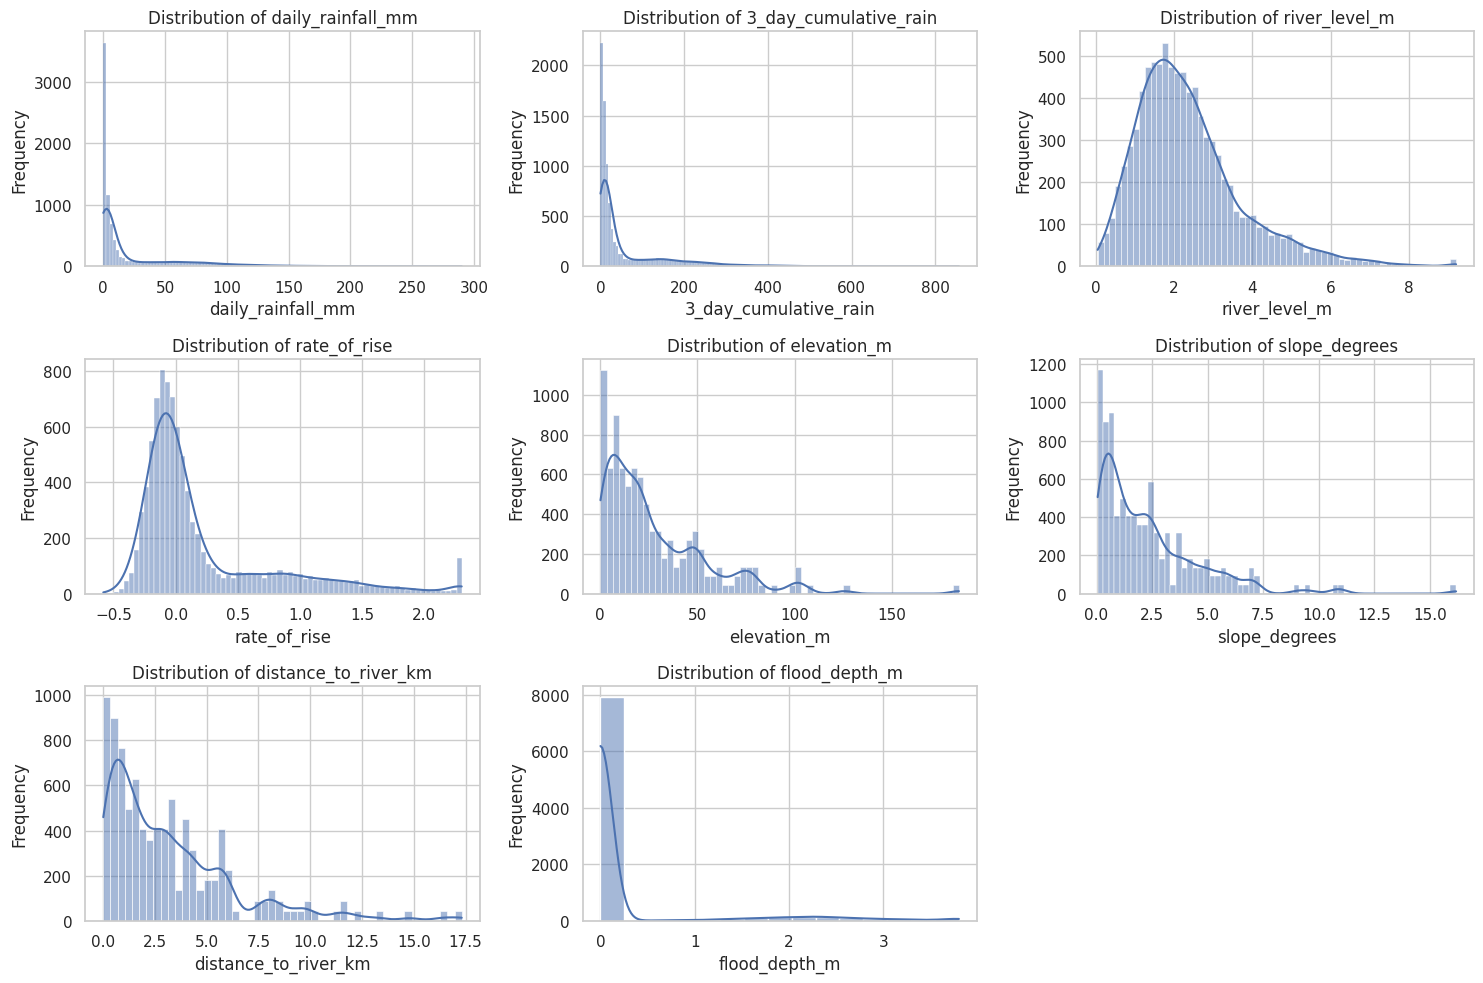

In [15]:
numerical_features = ['daily_rainfall_mm', '3_day_cumulative_rain', 'river_level_m', 'rate_of_rise', 'elevation_m', 'slope_degrees', 'distance_to_river_km', 'flood_depth_m']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)
Let's visualize target distributions, feature correlations, and hydrological relations.

/tmp/ipykernel_2497/2310103443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='flood_occurred', palette='Set2')


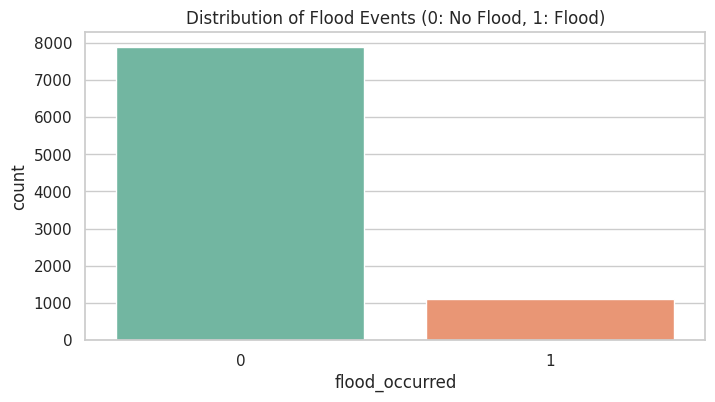

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='flood_occurred', palette='Set2')
plt.title('Distribution of Flood Events (0: No Flood, 1: Flood)')
plt.show()

### Correlation Heatmap

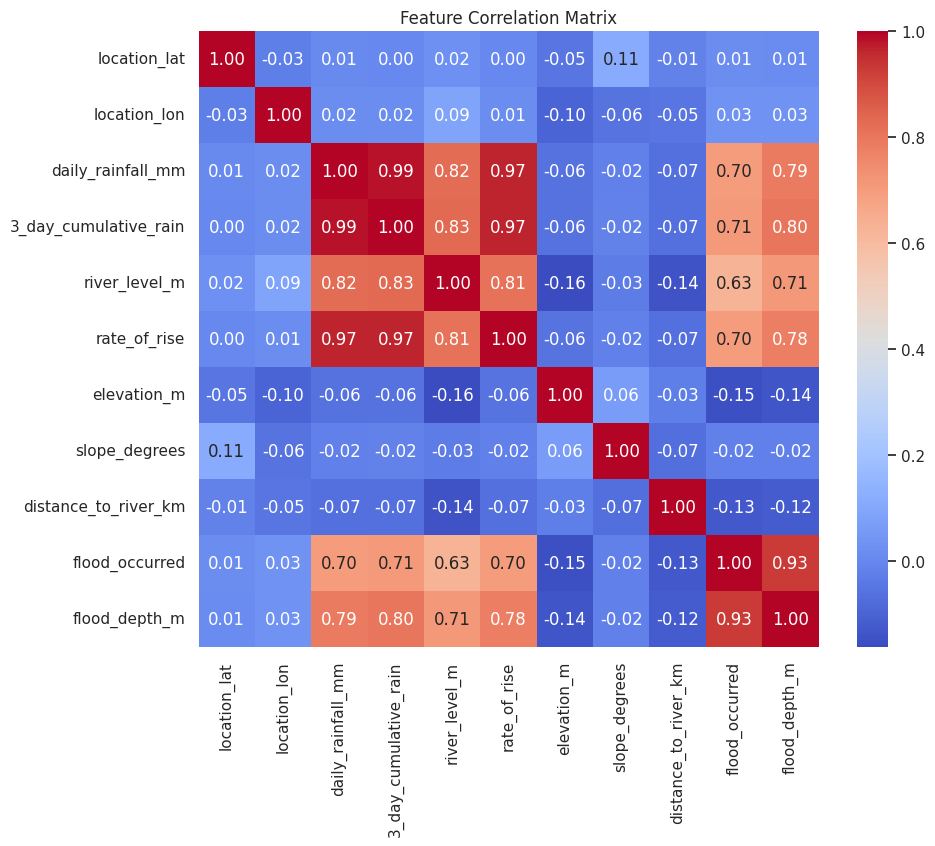

In [5]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### Hydrological Relationships: Daily Rainfall vs River Level

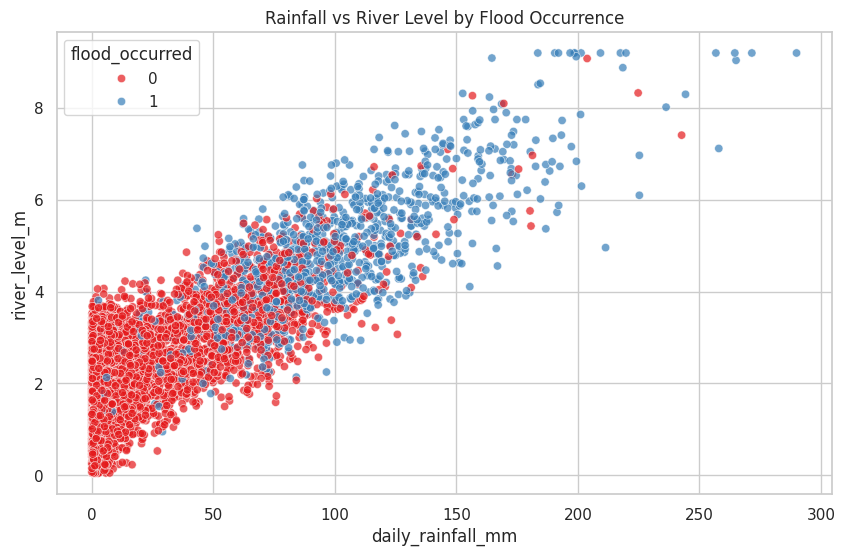

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='daily_rainfall_mm', y='river_level_m', hue='flood_occurred', palette='Set1', alpha=0.7)
plt.title('Rainfall vs River Level by Flood Occurrence')
plt.show()

## 4. Feature Mapping & Target Engineering

/tmp/ipykernel_2497/560893963.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_level', palette='viridis')


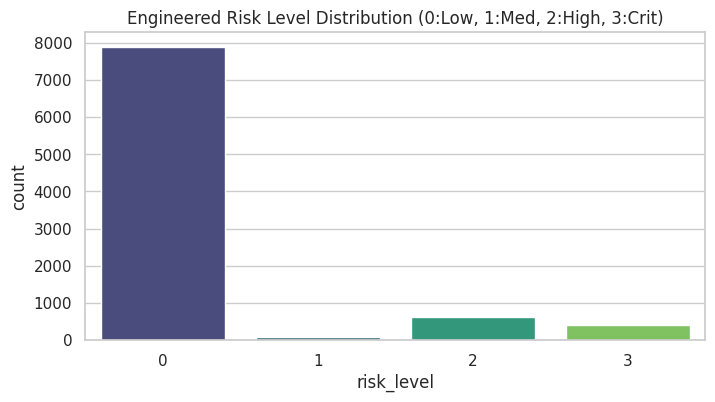

In [7]:
def map_risk_level(depth):
    if depth == 0.0:
        return 0
    elif depth <= 1.0:
        return 1
    elif depth <= 2.5:
        return 2
    else:
        return 3

df['risk_level'] = df['flood_depth_m'].apply(map_risk_level)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='risk_level', palette='viridis')
plt.title('Engineered Risk Level Distribution (0:Low, 1:Med, 2:High, 3:Crit)')
plt.show()

## 5. Model Training & Hyperparameter Tuning

In [25]:
feature_cols = ['daily_rainfall_mm', '3_day_cumulative_rain', 'rate_of_rise', 'elevation_m', 'slope_degrees', 'distance_to_river_km', 'year', 'month', 'day', 'dayofweek']
X = df[feature_cols]
y_class = df['risk_level']
y_depth = df['flood_depth_m']

X_train, X_test, y_c_train, y_c_test = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)
_, _, y_d_train, y_d_test = train_test_split(X, y_depth, test_size=0.2, random_state=42)

### Train and Optimize Random Forest Classifier

In [9]:
# Define grid search parameter space
rf_clf = RandomForestClassifier(random_state=42)
clf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5]
}
clf_grid = GridSearchCV(rf_clf, clf_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
clf_grid.fit(X_train, y_c_train)
best_clf = clf_grid.best_estimator_
print('Best Classifier parameters found:', clf_grid.best_params_)

Best Classifier parameters found: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}


### Evaluate Classifier

Test Accuracy: 0.9316666666666666
              precision    recall  f1-score   support

         Low       0.96      0.98      0.97      1580
      Medium       0.00      0.00      0.00        17
        High       0.61      0.54      0.58       123
    Critical       0.80      0.80      0.80        80

    accuracy                           0.93      1800
   macro avg       0.59      0.58      0.59      1800
weighted avg       0.92      0.93      0.93      1800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


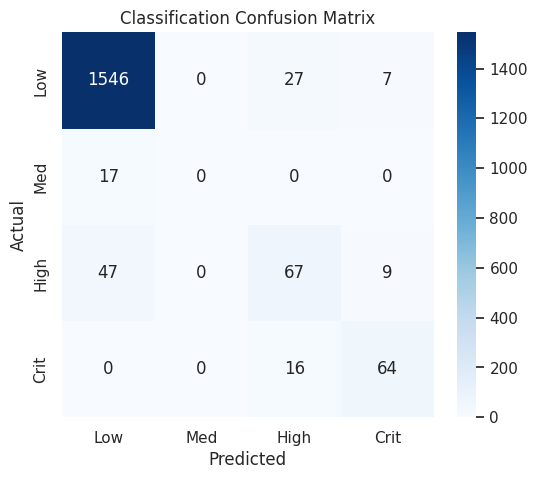

In [10]:
y_c_pred = best_clf.predict(X_test)
print('Test Accuracy:', accuracy_score(y_c_test, y_c_pred))
print(classification_report(y_c_test, y_c_pred, target_names=['Low', 'Medium', 'High', 'Critical']))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_c_test, y_c_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Med', 'High', 'Crit'], yticklabels=['Low', 'Med', 'High', 'Crit'])
plt.title('Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 5.1.1 Handling Class Imbalance with SMOTE

The classification report revealed poor performance for the 'Medium' risk level due to class imbalance. We will use SMOTE to oversample the minority classes in the training set to provide a more balanced dataset for training the classifier.

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_c_train_resampled = smote.fit_resample(X_train, y_c_train)

print('Original training target distribution:')
print(y_c_train.value_counts())
print('\nResampled training target distribution:')
print(y_c_train_resampled.value_counts())

Original training target distribution:
risk_level
0    6318
2     493
3     321
1      68
Name: count, dtype: int64

Resampled training target distribution:
risk_level
0    6318
2    6318
3    6318
1    6318
Name: count, dtype: int64


### 5.1.2 Re-train and Optimize Random Forest Classifier with Resampled Data

Now, let's retrain our Random Forest Classifier using the SMOTE-resampled training data and re-evaluate its performance.

In [17]:
# Define grid search parameter space
rf_clf_resampled = RandomForestClassifier(random_state=42)
clf_param_grid_resampled = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5]
}
clf_grid_resampled = GridSearchCV(rf_clf_resampled, clf_param_grid_resampled, cv=3, scoring='accuracy', n_jobs=-1)
clf_grid_resampled.fit(X_train_resampled, y_c_train_resampled)
best_clf_resampled = clf_grid_resampled.best_estimator_
print('Best Classifier parameters found (resampled data):', clf_grid_resampled.best_params_)

Best Classifier parameters found (resampled data): {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}


### 5.1.3 Evaluate Classifier (Resampled Data)

Let's evaluate the performance of the retrained classifier on the original test set.

Test Accuracy (resampled data): 0.7994444444444444
              precision    recall  f1-score   support

         Low       0.99      0.80      0.88      1580
      Medium       0.04      0.53      0.08        17
        High       0.45      0.80      0.57       123
    Critical       0.77      0.80      0.79        80

    accuracy                           0.80      1800
   macro avg       0.56      0.73      0.58      1800
weighted avg       0.93      0.80      0.85      1800



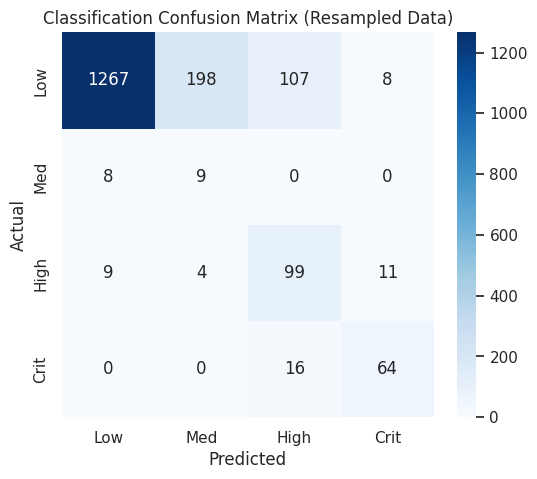

In [18]:
y_c_pred_resampled = best_clf_resampled.predict(X_test)
print('Test Accuracy (resampled data):', accuracy_score(y_c_test, y_c_pred_resampled))
print(classification_report(y_c_test, y_c_pred_resampled, target_names=['Low', 'Medium', 'High', 'Critical']))

# Confusion Matrix Heatmap
cm_resampled = confusion_matrix(y_c_test, y_c_pred_resampled)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Med', 'High', 'Crit'], yticklabels=['Low', 'Med', 'High', 'Crit'])
plt.title('Classification Confusion Matrix (Resampled Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5.2 Feature Importance Analysis

Understanding the importance of each feature for our models can provide valuable insights into the flood prediction process and help in feature selection or further data collection efforts.

### 5.2.1 Classifier Feature Importance (Resampled Data)

Let's visualize the feature importances for the Random Forest Classifier that was trained with SMOTE-resampled data.

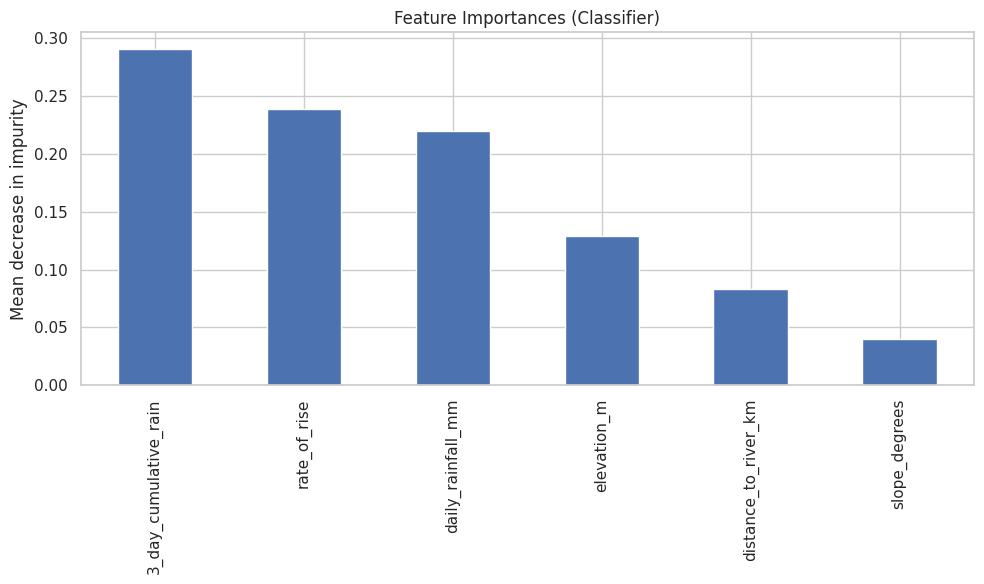

In [19]:
importances_clf = best_clf_resampled.feature_importances_
feature_names = X.columns
forest_importances_clf = pd.Series(importances_clf, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances_clf.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances (Classifier)")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

### 5.2.2 Regressor Feature Importance

Now, let's look at the feature importances for the Random Forest Regressor.

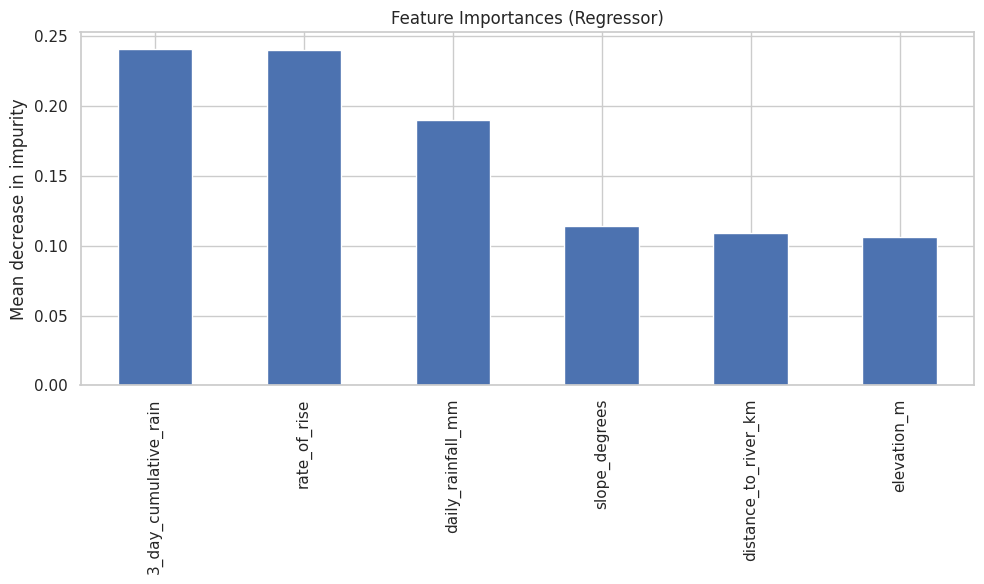

In [20]:
importances_reg = best_reg.feature_importances_
feature_names = X.columns
forest_importances_reg = pd.Series(importances_reg, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances_reg.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances (Regressor)")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## 6. Model Persistence

To make our trained models reusable without retraining, we will save the `best_clf_resampled` (classifier) and `best_reg` (regressor) using the `pickle` module.

In [21]:
# Create a directory for models if it doesn't exist
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

# Save the best classifier model
classifier_filename = os.path.join(model_dir, 'flood_risk_classifier.pkl')
with open(classifier_filename, 'wb') as file:
    pickle.dump(best_clf_resampled, file)
print(f'Best classifier model saved to {classifier_filename}')

# Save the best regressor model
regressor_filename = os.path.join(model_dir, 'flood_depth_regressor.pkl')
with open(regressor_filename, 'wb') as file:
    pickle.dump(best_reg, file)
print(f'Best regressor model saved to {regressor_filename}')

Best classifier model saved to models/flood_risk_classifier.pkl
Best regressor model saved to models/flood_depth_regressor.pkl


### Loading the models (for demonstration)

This is how you would load the saved models back into memory.

In [22]:
# Load the classifier model
with open(classifier_filename, 'rb') as file:
    loaded_classifier = pickle.load(file)
print(f'Loaded classifier model: {loaded_classifier}')

# Load the regressor model
with open(regressor_filename, 'rb') as file:
    loaded_regressor = pickle.load(file)
print(f'Loaded regressor model: {loaded_regressor}')

# You can now use loaded_classifier and loaded_regressor for predictions

Loaded classifier model: RandomForestClassifier(max_depth=10, n_estimators=150, random_state=42)
Loaded regressor model: RandomForestRegressor(max_depth=6, n_estimators=150, random_state=42)


## 7. Feature Scaling/Normalization

While tree-based models like Random Forests are not sensitive to feature scaling, it is a crucial preprocessing step for many other machine learning algorithms. Applying `StandardScaler` now will ensure our data is ready for a wider range of models and maintain consistency in our preprocessing pipeline.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the original feature set X
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Original features (first 5 rows):')
display(X.head())
print('\nScaled features (first 5 rows):')
display(X_scaled_df.head())

# Note: For actual model training, you would apply the scaler to X_train and X_test separately:
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# We're just demonstrating the scaling here on the full X for simplicity.

Original features (first 5 rows):


,daily_rainfall_mm,3_day_cumulative_rain,rate_of_rise,elevation_m,slope_degrees,distance_to_river_km
0,34.0,63.3,0.397,2.2,0.2,0.74
1,7.6,18.9,0.207,2.2,0.2,0.74
2,141.2,408.5,2.300,2.2,0.2,0.74
3,0.3,1.2,-0.182,2.2,0.2,0.74
4,2.1,14.3,-0.126,2.2,0.2,0.74



Scaled features (first 5 rows):


,daily_rainfall_mm,3_day_cumulative_rain,rate_of_rise,elevation_m,slope_degrees,distance_to_river_km
0,0.300072,0.036350,0.303867,-0.939892,-0.9076,-0.785539
1,-0.403720,-0.437937,-0.026966,-0.939892,-0.9076,-0.785539
2,3.157895,3.723826,3.617417,-0.939892,-0.9076,-0.785539
3,-0.598330,-0.627011,-0.704302,-0.939892,-0.9076,-0.785539
4,-0.550344,-0.487075,-0.606793,-0.939892,-0.9076,-0.785539


### Train and Optimize Random Forest Regressor

In [26]:
rf_reg = RandomForestRegressor(random_state=42)
reg_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5]
}
reg_grid = GridSearchCV(rf_reg, reg_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
reg_grid.fit(X_train, y_d_train)
best_reg = reg_grid.best_estimator_
print('Best Regressor parameters found:', reg_grid.best_params_)

Best Regressor parameters found: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 150}


### Evaluate Regressor

In [27]:
y_d_pred = best_reg.predict(X_test)
mse = mean_squared_error(y_d_test, y_d_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_d_test, y_d_pred)
print(f'Test MSE: {mse:.4f}')
print(f'Test RMSE: {rmse:.4f} meters')
print(f'Test MAE: {mae:.4f} meters')

Test MSE: 0.6831
Test RMSE: 0.8265 meters
Test MAE: 0.4940 meters


### 5.3 Evaluate Regressor with R-squared

Let's add the R-squared metric to our regression model evaluation to understand how much of the variance in flood depth is explained by our features.

In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_d_test, y_d_pred)
print(f'Test R-squared: {r2:.4f}')

Test R-squared: 0.0009


## 8. In-depth Analysis of `flood_depth_m` Distribution and Outliers

The persistently low R-squared for the regression model suggests issues with how `flood_depth_m` is being modeled. Let's analyze its distribution more closely, especially considering the large number of zero values.

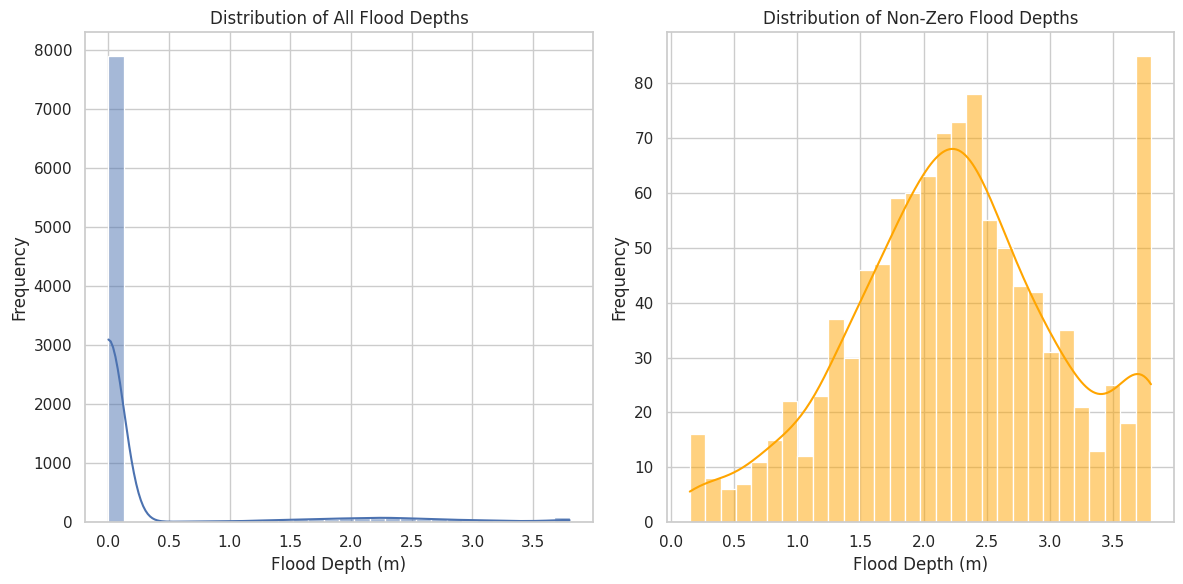

Number of zero flood depth instances: 7898 (87.76%)
Number of non-zero flood depth instances: 1102 (12.24%)


In [29]:
plt.figure(figsize=(12, 6))

# Distribution of all flood depths
sns.histplot(df['flood_depth_m'], bins=30, kde=True, ax=plt.subplot(1, 2, 1))
plt.title('Distribution of All Flood Depths')
plt.xlabel('Flood Depth (m)')
plt.ylabel('Frequency')

# Distribution of non-zero flood depths
non_zero_flood_depth = df[df['flood_depth_m'] > 0]['flood_depth_m']
sns.histplot(non_zero_flood_depth, bins=30, kde=True, ax=plt.subplot(1, 2, 2), color='orange')
plt.title('Distribution of Non-Zero Flood Depths')
plt.xlabel('Flood Depth (m)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Number of zero flood depth instances: {(df["flood_depth_m"] == 0).sum()} ({((df["flood_depth_m"] == 0).sum() / len(df)):.2%})')
print(f'Number of non-zero flood depth instances: {non_zero_flood_depth.count()} ({((non_zero_flood_depth.count() / len(df))):.2%})')

### Potential Outlier Analysis for Non-Zero Flood Depths

Let's check for potential outliers in the *non-zero* flood depth values using a box plot, as these could influence our regression model.

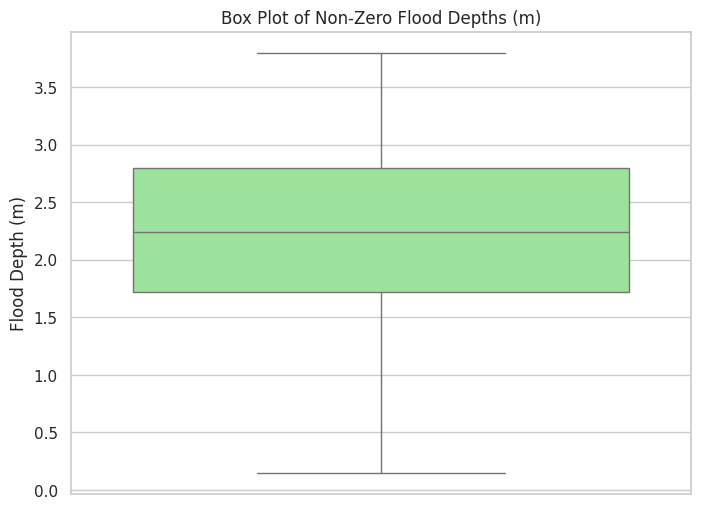

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=non_zero_flood_depth, color='lightgreen')
plt.title('Box Plot of Non-Zero Flood Depths (m)')
plt.ylabel('Flood Depth (m)')
plt.show()

## 9. Two-Stage Modeling for Flood Depth Prediction

Given the highly skewed distribution of `flood_depth_m` (with a large number of zero values), a two-stage modeling approach is more appropriate:
1.  **Stage 1 (Classification)**: Predict whether a flood will occur (`flood_occurred`).
2.  **Stage 2 (Regression)**: Predict `flood_depth_m` *only for instances where a flood is predicted to occur*.

### 9.1 Stage 1: Predict `flood_occurred` (Binary Classification)

We will train a Random Forest Classifier to predict the `flood_occurred` target. This is a binary classification problem.

In [31]:
# Define the target for flood occurrence
y_flood_occurred = df['flood_occurred']

# Split data for the flood occurrence classifier
X_train_fo, X_test_fo, y_train_fo, y_test_fo = train_test_split(X, y_flood_occurred, test_size=0.2, random_state=42, stratify=y_flood_occurred)

# Train and optimize Random Forest Classifier for flood occurrence
rf_fo_clf = RandomForestClassifier(random_state=42)
fo_clf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5]
}
fo_clf_grid = GridSearchCV(rf_fo_clf, fo_clf_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
fo_clf_grid.fit(X_train_fo, y_train_fo)
best_fo_clf = fo_clf_grid.best_estimator_
print('Best Flood Occurrence Classifier parameters found:', fo_clf_grid.best_params_)

Best Flood Occurrence Classifier parameters found: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}


### 9.1.1 Evaluate Flood Occurrence Classifier

Let's evaluate the performance of the classifier that predicts `flood_occurred`.

Flood Occurrence Classifier Test Accuracy: 0.945

Flood Occurrence Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1580
           1       0.80      0.73      0.76       220

    accuracy                           0.94      1800
   macro avg       0.88      0.85      0.87      1800
weighted avg       0.94      0.94      0.94      1800



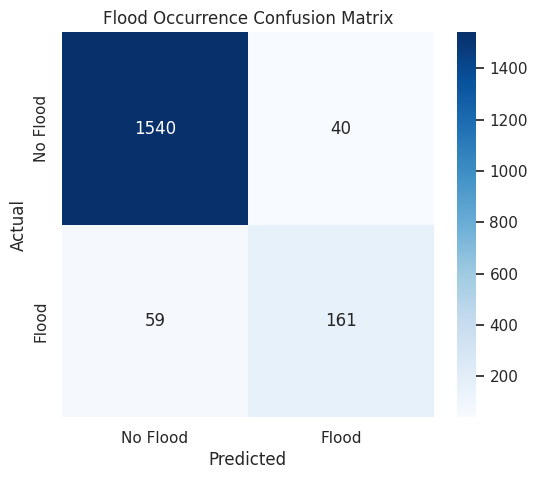

In [32]:
y_pred_fo = best_fo_clf.predict(X_test_fo)

print('Flood Occurrence Classifier Test Accuracy:', accuracy_score(y_test_fo, y_pred_fo))
print('\nFlood Occurrence Classification Report:')
print(classification_report(y_test_fo, y_pred_fo))

# Confusion Matrix for flood occurrence
cm_fo = confusion_matrix(y_test_fo, y_pred_fo)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_fo, annot=True, fmt='d', cmap='Blues', xticklabels=['No Flood', 'Flood'], yticklabels=['No Flood', 'Flood'])
plt.title('Flood Occurrence Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 9.2 Stage 2: Predict `flood_depth_m` for Flood Occurrences (Regression)

Now, we will train a regression model *only* on the data points where `flood_occurred` is 1, to predict the actual `flood_depth_m`.

In [33]:
# Filter the DataFrame to include only instances where flood_occurred is 1
df_flood_only = df[df['flood_occurred'] == 1].copy()

# Define features (X_reg_fo) and target (y_reg_fo) for the flood-only regression model
X_reg_fo = df_flood_only[feature_cols]
y_reg_fo = df_flood_only['flood_depth_m']

# Split data for the flood depth regressor (flood-only)
X_train_reg_fo, X_test_reg_fo, y_train_reg_fo, y_test_reg_fo = train_test_split(X_reg_fo, y_reg_fo, test_size=0.2, random_state=42)

# Train and optimize Random Forest Regressor for flood depth (flood-only)
rf_reg_fo = RandomForestRegressor(random_state=42)
reg_fo_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5]
}
reg_fo_grid = GridSearchCV(rf_reg_fo, reg_fo_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
reg_fo_grid.fit(X_train_reg_fo, y_train_reg_fo)
best_reg_fo = reg_fo_grid.best_estimator_
print('Best Flood Depth Regressor parameters found (flood-only):', reg_fo_grid.best_params_)

Best Flood Depth Regressor parameters found (flood-only): {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 150}


### 9.2.1 Evaluate Flood Depth Regressor (Flood-Only)

Flood-Only Regressor Test MSE: 0.0715
Flood-Only Regressor Test RMSE: 0.2674 meters
Flood-Only Regressor Test MAE: 0.2056 meters
Flood-Only Regressor Test R-squared: 0.8978


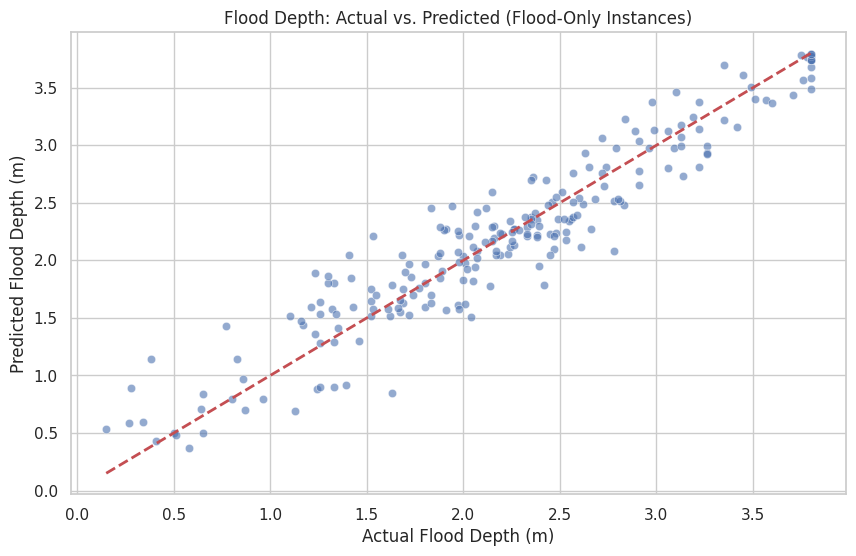

In [34]:
y_pred_reg_fo = best_reg_fo.predict(X_test_reg_fo)

mse_fo = mean_squared_error(y_test_reg_fo, y_pred_reg_fo)
rmse_fo = np.sqrt(mse_fo)
mae_fo = mean_absolute_error(y_test_reg_fo, y_pred_reg_fo)
r2_fo = r2_score(y_test_reg_fo, y_pred_reg_fo)

print(f'Flood-Only Regressor Test MSE: {mse_fo:.4f}')
print(f'Flood-Only Regressor Test RMSE: {rmse_fo:.4f} meters')
print(f'Flood-Only Regressor Test MAE: {mae_fo:.4f} meters')
print(f'Flood-Only Regressor Test R-squared: {r2_fo:.4f}')

# Visualize predictions vs actual values for flood depths
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_reg_fo, y=y_pred_reg_fo, alpha=0.6)
plt.plot([y_test_reg_fo.min(), y_test_reg_fo.max()], [y_test_reg_fo.min(), y_test_reg_fo.max()], 'r--', lw=2)
plt.title('Flood Depth: Actual vs. Predicted (Flood-Only Instances)')
plt.xlabel('Actual Flood Depth (m)')
plt.ylabel('Predicted Flood Depth (m)')
plt.grid(True)
plt.show()